In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 4)

# Prosperity Trading — Exploratory Data Analysis

Two days of simulated exchange data for two products: **EMERALDS** and **TOMATOES**.

- `prices_round_0_day_X.csv` — order book snapshots every 100 timestamps (best 3 bid/ask levels + mid price)
- `trades_round_0_day_X.csv` — individual trades that occurred (price, quantity, buyer, seller)

In [24]:
# Load price (order book) data
prices_d1 = pd.read_csv("../data/prices_round_0_day_-1.csv", sep=";")
prices_d2 = pd.read_csv("../data/prices_round_0_day_-2.csv", sep=";")
prices = pd.concat([prices_d2, prices_d1], ignore_index=True)

# Load trade data — add day column so we can split per day later
trades_d1 = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")
trades_d2 = pd.read_csv("../data/trades_round_0_day_-2.csv", sep=";")
trades_d1["day"] = -1
trades_d2["day"] = -2
trades = pd.concat([trades_d2, trades_d1], ignore_index=True)

products = sorted(prices["product"].unique())
days = sorted(prices["day"].unique())

print("prices shape:", prices.shape)
print("trades shape:", trades.shape)
print(f"Timestamps range: {prices['timestamp'].min()} → {prices['timestamp'].max()}, step 100 → {prices['timestamp'].nunique()} snapshots/product/day")
prices.head()

prices shape: (40000, 17)
trades shape: (1219, 8)
Timestamps range: 0 → 999900, step 100 → 10000 snapshots/product/day


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0


In [25]:
trades.head()

,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2,-2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3,-2
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7,-2
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3,-2
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5,-2


In [26]:
prices_emerald = prices[prices["product"] == "EMERALDS"]
prices_emerald = prices_emerald.drop(columns=["product"])
prices_tomatoes = prices[prices["product"] == "TOMATOES"]
prices_tomatoes = prices_tomatoes.drop(columns=["product"])

trades_emerald = trades[trades["symbol"] == "EMERALDS"].drop(columns=["symbol"])
trades_tomatoes = trades[trades["symbol"] == "TOMATOES"].drop(columns=["symbol"])

In [27]:
print(prices_emerald.head())

   day  timestamp  bid_price_1  bid_volume_1  bid_price_2  bid_volume_2  \
0   -2          0         9992            11         9990            25   
3   -2        100         9992            15         9990            20   
5   -2        200         9992            15         9990            30   
6   -2        300         9992            13         9990            26   
8   -2        400         9992            15         9990            20   

   bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  ask_price_2  \
0          NaN           NaN        10008            11        10010   
3          NaN           NaN        10008            15        10010   
5          NaN           NaN        10008            15        10010   
6          NaN           NaN        10008            13        10010   
8          NaN           NaN        10008            15        10010   

   ask_volume_2  ask_price_3  ask_volume_3  mid_price  profit_and_loss  
0            25          NaN           NaN 

In [28]:
trades_tomatoes["price"].describe()

count     820.000000
mean     4992.571951
std        21.130467
min      4943.000000
25%      4978.000000
50%      4994.000000
75%      5008.000000
max      5040.000000
Name: price, dtype: float64

## 1. Mid-Price Over Time

Timestamps run from 0 to ~1,000,000 in steps of 100, giving **10,000 order book snapshots per product per day** — so 1M is the total timestamp range, not the number of rows.

Y-axis is zoomed in tightly per product so small moves are visible.

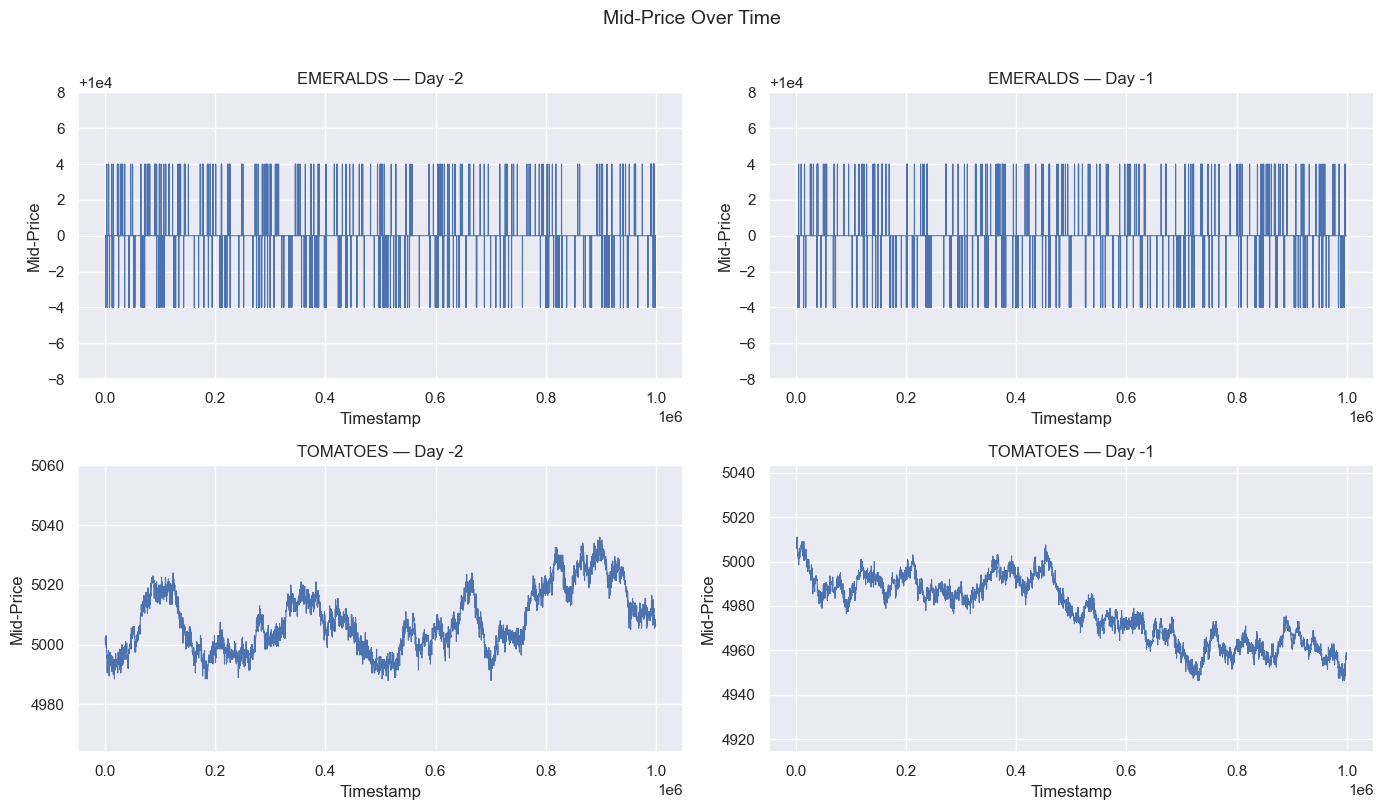

In [29]:
fig, axes = plt.subplots(len(products), len(days), figsize=(14, 4 * len(products)))

for row, product in enumerate(products):
    for col, day in enumerate(days):
        ax = axes[row, col]
        subset = prices[(prices["product"] == product) & (prices["day"] == day)]
        ax.plot(subset["timestamp"], subset["mid_price"], linewidth=0.8)

        lo, hi = subset["mid_price"].min(), subset["mid_price"].max()
        margin = max((hi - lo) * 0.5, 2)
        ax.set_ylim(lo - margin, hi + margin)

        ax.set_title(f"{product} — Day {day}")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Mid-Price")

plt.suptitle("Mid-Price Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Bid-Ask Spread

The spread = best ask − best bid. A tight spread means the market is liquid. A wide spread means more uncertainty or less competition.  
For a trading bot, the spread is a key cost to beat — if you buy at the ask and sell at the bid, you pay the spread.

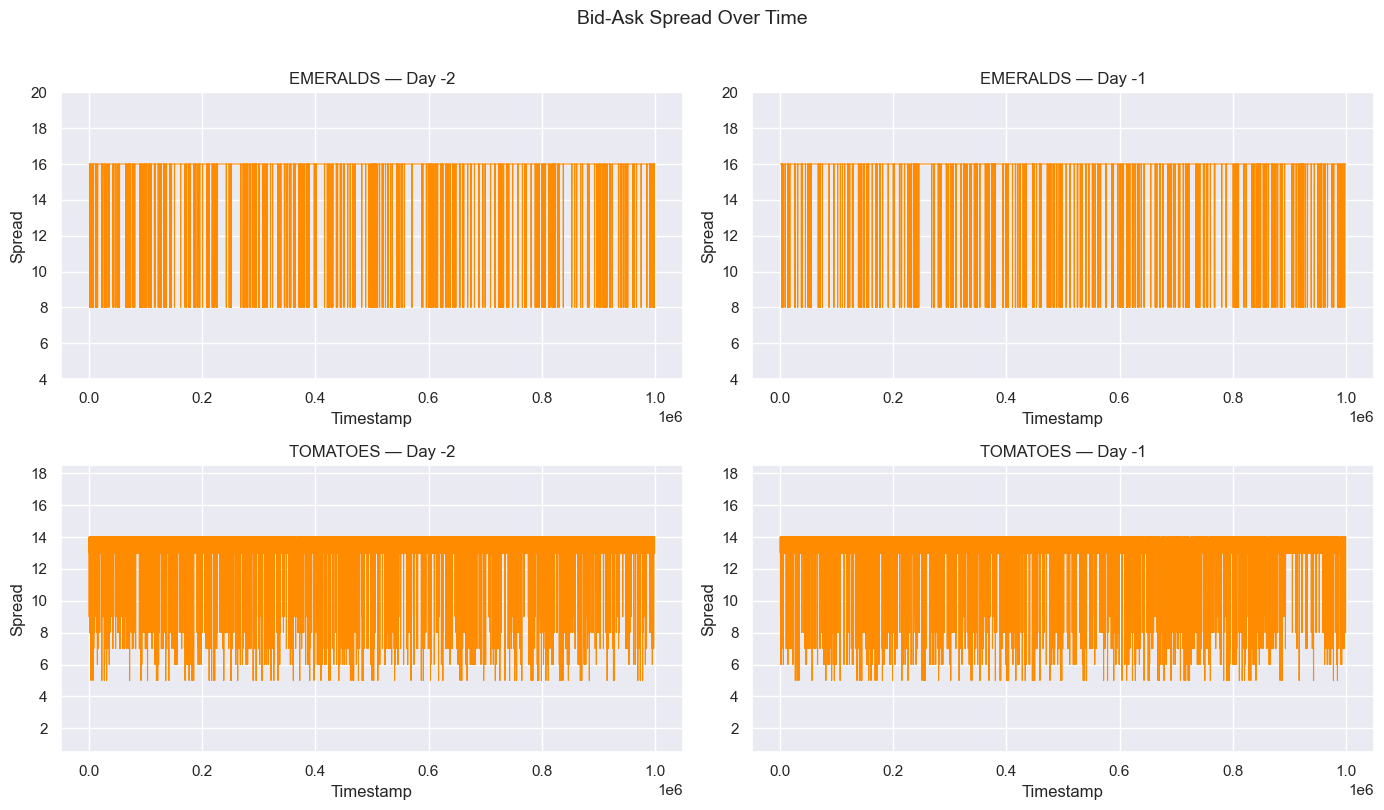

Mean spread per product per day:
                count   mean   std  min   25%   50%   75%   max
product  day                                                   
EMERALDS -2   10000.0  15.73  1.44  8.0  16.0  16.0  16.0  16.0
         -1   10000.0  15.74  1.41  8.0  16.0  16.0  16.0  16.0
TOMATOES -2   10000.0  13.07  1.75  5.0  13.0  13.0  14.0  14.0
         -1   10000.0  12.98  1.75  5.0  13.0  13.0  14.0  14.0


In [30]:
prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]

fig, axes = plt.subplots(len(products), len(days), figsize=(14, 4 * len(products)))

for row, product in enumerate(products):
    for col, day in enumerate(days):
        ax = axes[row, col]
        subset = prices[(prices["product"] == product) & (prices["day"] == day)]
        ax.plot(subset["timestamp"], subset["spread"], linewidth=0.8, color="darkorange")

        lo, hi = subset["spread"].min(), subset["spread"].max()
        margin = max((hi - lo) * 0.5, 0.5)
        ax.set_ylim(lo - margin, hi + margin)

        ax.set_title(f"{product} — Day {day}")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Spread")

plt.suptitle("Bid-Ask Spread Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Mean spread per product per day:")
print(prices.groupby(["product", "day"])["spread"].describe().round(2))

## 3. Order Book Depth

Each snapshot has up to 3 bid and 3 ask levels. Looking at total volume available at each side tells you how much liquidity exists and how aggressive the order book is.

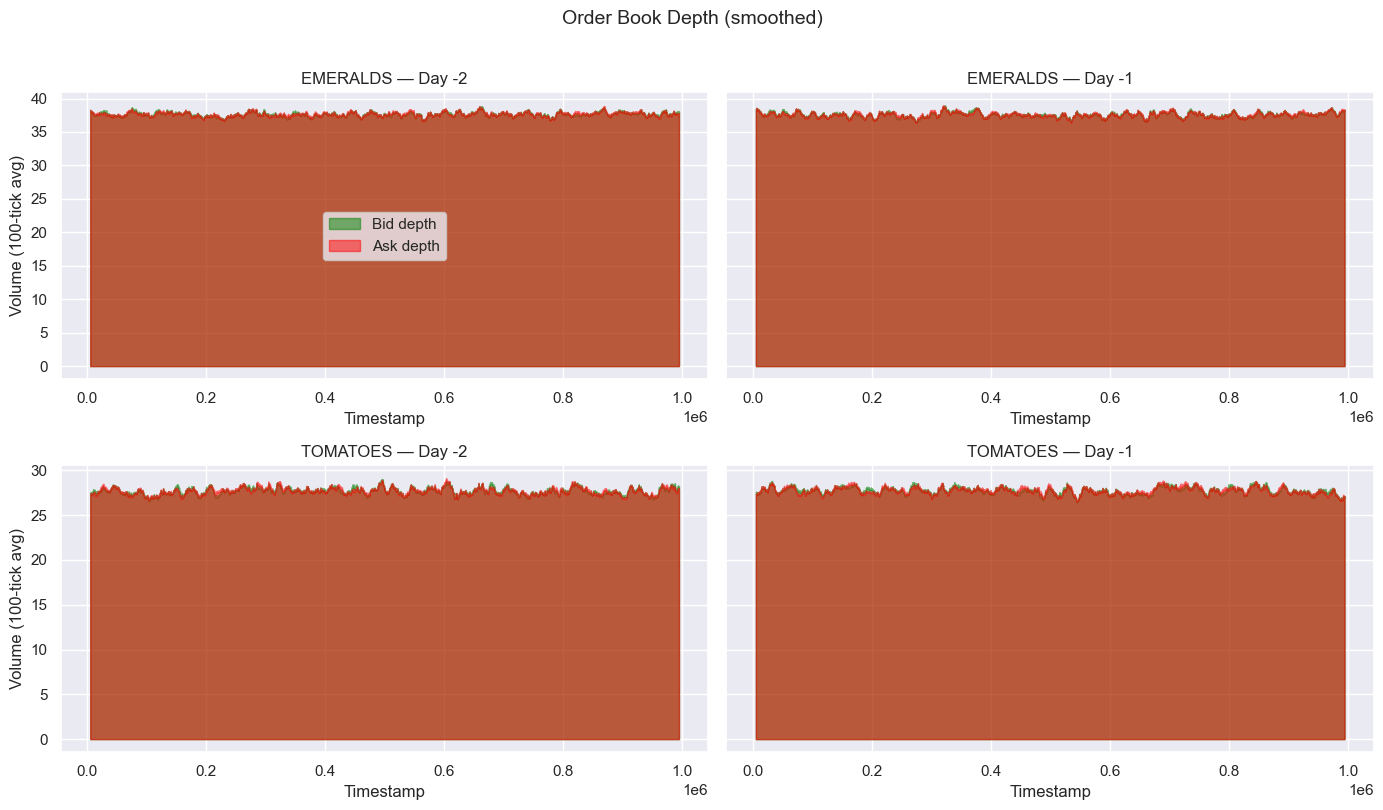

In [31]:
bid_vol_cols = ["bid_volume_1", "bid_volume_2", "bid_volume_3"]
ask_vol_cols = ["ask_volume_1", "ask_volume_2", "ask_volume_3"]
prices["total_bid_vol"] = prices[bid_vol_cols].fillna(0).sum(axis=1)
prices["total_ask_vol"] = prices[ask_vol_cols].fillna(0).sum(axis=1)

# Raw volume is very spiky — use a rolling mean to reveal the trend
window = 100

fig, axes = plt.subplots(len(products), len(days), figsize=(14, 4 * len(products)), sharey="row")

for row, product in enumerate(products):
    for col, day in enumerate(days):
        ax = axes[row, col]
        subset = prices[(prices["product"] == product) & (prices["day"] == day)].copy()
        bid_smooth = subset["total_bid_vol"].rolling(window, center=True).mean()
        ask_smooth = subset["total_ask_vol"].rolling(window, center=True).mean()
        ax.fill_between(subset["timestamp"], bid_smooth, alpha=0.5, label="Bid depth", color="green")
        ax.fill_between(subset["timestamp"], ask_smooth, alpha=0.5, label="Ask depth", color="red")
        ax.set_title(f"{product} — Day {day}")
        ax.set_xlabel("Timestamp")
        if col == 0:
            ax.set_ylabel("Volume (100-tick avg)")
        if row == 0 and col == 0:
            ax.legend()

plt.suptitle("Order Book Depth (smoothed)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Trade Price vs Mid-Price

Overlaying actual trade prices on top of the mid-price shows whether trades happen at, above, or below the midpoint — useful for detecting aggressive buyers/sellers.

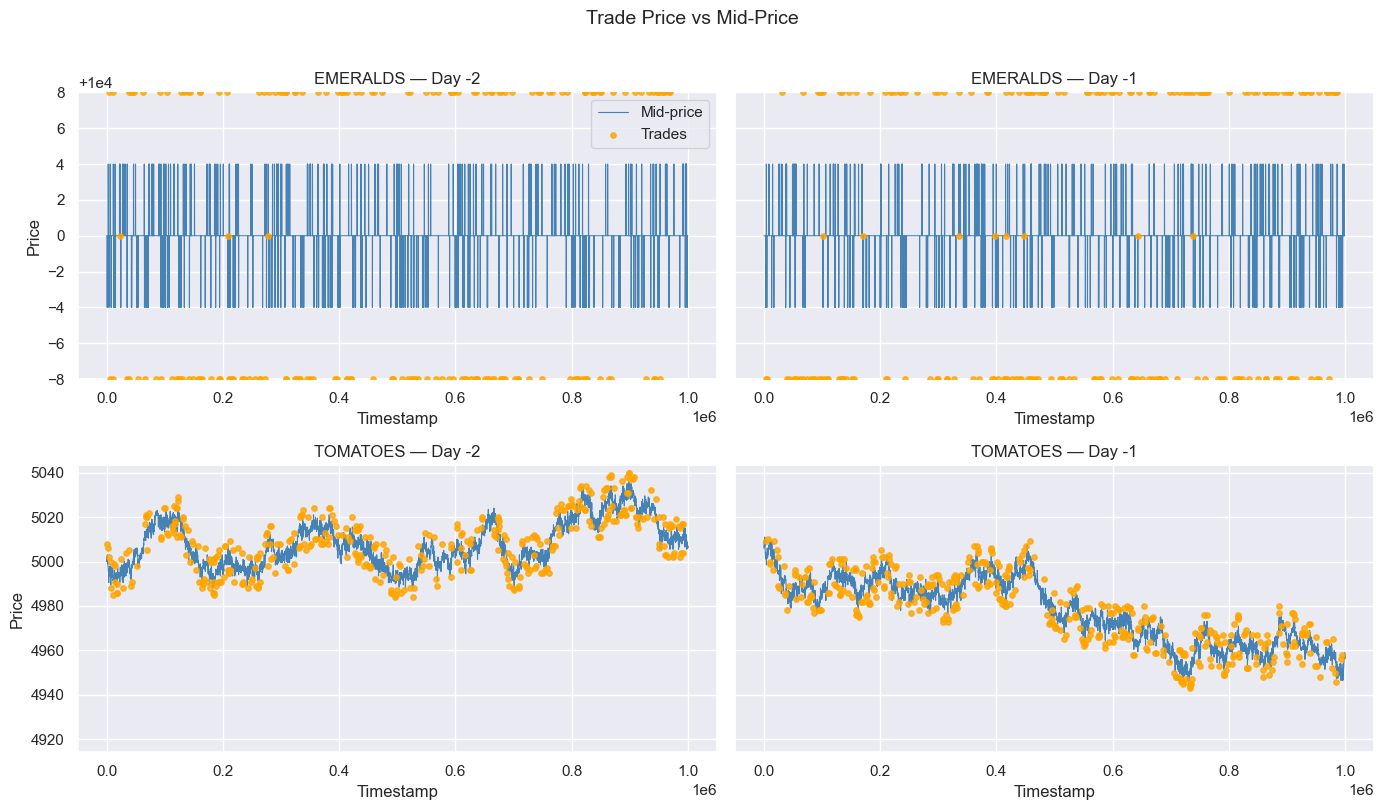

In [32]:
fig, axes = plt.subplots(len(products), len(days), figsize=(14, 4 * len(products)), sharey="row")

for row, product in enumerate(products):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mid = prices[(prices["product"] == product) & (prices["day"] == day)]
        t = trades[(trades["symbol"] == product) & (trades["day"] == day)]

        ax.plot(mid["timestamp"], mid["mid_price"], linewidth=0.8, color="steelblue", label="Mid-price")
        ax.scatter(t["timestamp"], t["price"], color="orange", s=15, zorder=5, alpha=0.8, label="Trades")

        # Tight y-axis based on mid-price range
        lo, hi = mid["mid_price"].min(), mid["mid_price"].max()
        margin = max((hi - lo) * 0.5, 2)
        ax.set_ylim(lo - margin, hi + margin)

        ax.set_title(f"{product} — Day {day}")
        ax.set_xlabel("Timestamp")
        if col == 0:
            ax.set_ylabel("Price")
        if row == 0 and col == 0:
            ax.legend()

plt.suptitle("Trade Price vs Mid-Price", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Log Returns

Log return at time t = ln(mid_price_t) − ln(mid_price_{t−1}). Computed within each day (so there is no spurious jump at the day boundary).

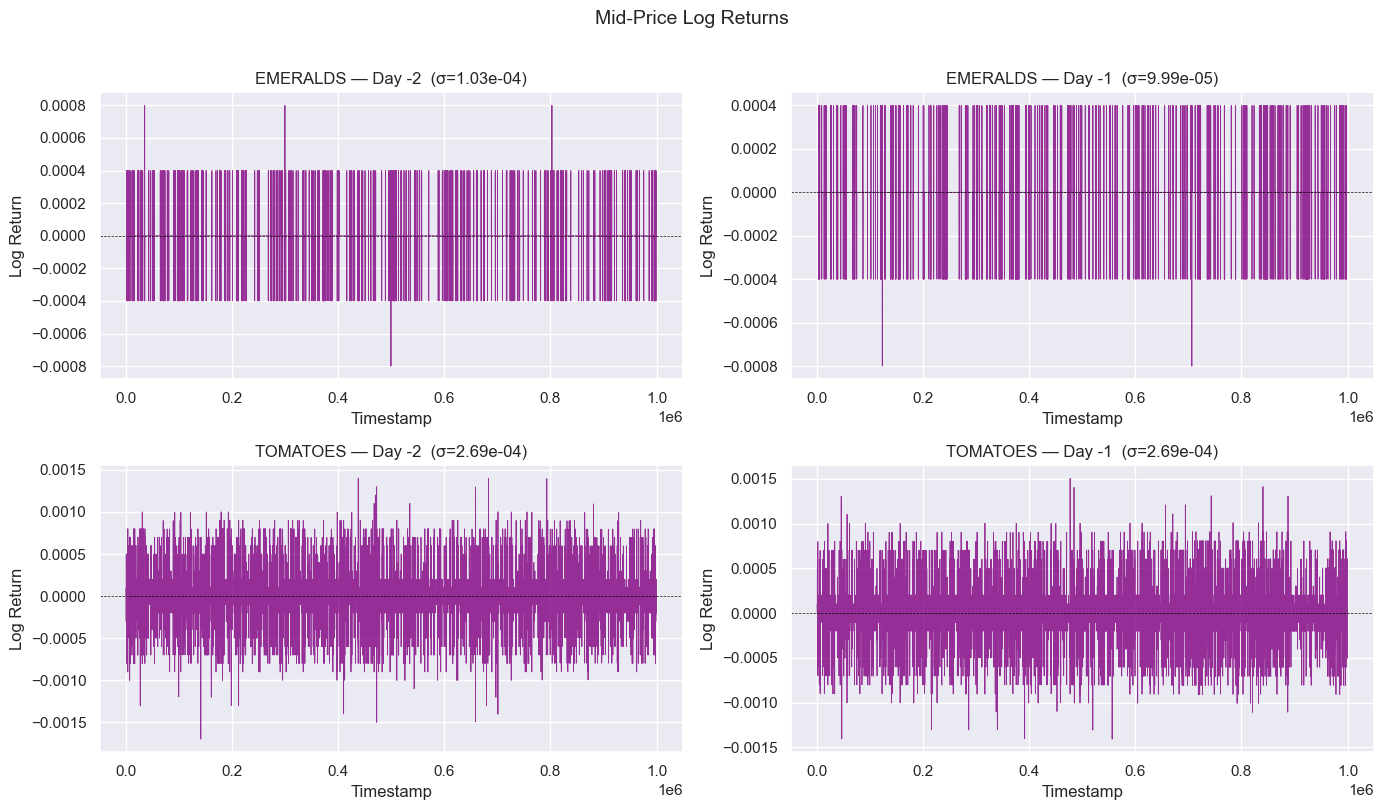

In [33]:
fig, axes = plt.subplots(len(products), len(days), figsize=(14, 4 * len(products)))

for row, product in enumerate(products):
    for col, day in enumerate(days):
        ax = axes[row, col]
        subset = prices[(prices["product"] == product) & (prices["day"] == day)].sort_values("timestamp")
        log_ret = np.log(subset["mid_price"]).diff()

        ax.plot(subset["timestamp"], log_ret, linewidth=0.6, color="purple", alpha=0.8)
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        ax.set_title(f"{product} — Day {day}  (σ={log_ret.std():.2e})")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Log Return")

plt.suptitle("Mid-Price Log Returns", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()